# Modelo Causal — IPTW

**Objetivo:** Estimar o efeito causal de fatores operacionais sobre a satisfação do cliente em pedidos entregues.

## Configuração

| Item | Valor |
|---|---|
| **Filtro** | `order_status == 'delivered'` |
| **Outcome** | `score_review` (0 = score ∈ {3,4,5}; 1 = score ∈ {1,2}) |
| **Modelo PS** | Logistic Regression |
| **Bootstrap** | n=200, logistic |
| **Pesos** | Estabilizados, clipe p99 |

## Análises

| # | Tratamento | Definição | Domínio |
|---|---|---|---|
| 1 | `is_delayed` | delay_days > 0 | Logístico |

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from app.config.settings import INTERIM_DATA_DIR
from app.data import get_features
from app.data.utils import find_specific_variables
from app.utils.report_functions import run_iptw_analysis

In [2]:
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)

## 2. Carregamento dos dados

In [3]:
df = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, 'interim_dataset.parquet'))

print(df.shape)
df.head()

(95832, 30)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,...,avg_width,total_payment,avg_payment,max_installments,n_payments_type,review_score,review_score_outcome,is_delayed,purchase_weekday,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,SP,...,13.0000,38.7100,12.9033,1.0000,3.0000,4.0000,0,0,0,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,barreiras,BA,...,19.0000,141.4600,141.4600,1.0000,1.0000,4.0000,0,0,1,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,vianopolis,GO,...,21.0000,179.1200,179.1200,3.0000,1.0000,5.0000,0,0,2,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,sao goncalo do amarante,RN,...,20.0000,72.2000,72.2000,1.0000,1.0000,5.0000,0,0,5,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,santo andre,SP,...,15.0000,28.6200,28.6200,1.0000,1.0000,5.0000,0,0,1,2


In [4]:
features = get_features('features.yaml')

In [5]:
confounders = find_specific_variables(features, "confounder", specific_value = True)
confounders

['total_price',
 'avg_price',
 'total_freight',
 'avg_freight',
 'n_items',
 'n_items_missing_info',
 'n_item_distinct_categ',
 'avg_weight',
 'avg_length',
 'avg_height',
 'avg_width',
 'total_payment',
 'avg_payment',
 'n_payments_type',
 'purchase_weekday',
 'purchase_month']

In [6]:
treatment = find_specific_variables(features, "treatment", specific_value = True)[0]
treatment

'is_delayed'

In [7]:
outcome = find_specific_variables(features, "outcome", specific_value = True)[0]
outcome

'review_score_outcome'

IPTW: is_delayed -> review_score_outcome
Shape before preprocessing: 95,832
Shape after preprocessing: 95,815

AUC-ROC PS: 0.5727
PS     — media: 0.067 | min: 0.010 | max: 0.726
Pesos  — media: 0.999 | min: 0.196 | max: 1.228

--- Balanco das covariaveis (SMD < 0.1 = OK) ---
                       SMD antes  SMD depois Balanceado?
total_price               0.0639      0.0148          OK
avg_price                 0.0849      0.0261          OK
total_freight             0.1142      0.0303          OK
avg_freight               0.1758      0.0537          OK
n_items                   0.0646      0.0273          OK
n_items_missing_info      0.0152      0.0014          OK
n_item_distinct_categ     0.0673      0.0270          OK
avg_weight                0.0951      0.0250          OK
avg_length                0.0713      0.0166          OK
avg_height                0.0586      0.0149          OK
avg_width                 0.0348      0.0109          OK
total_payment             0.0724      0.

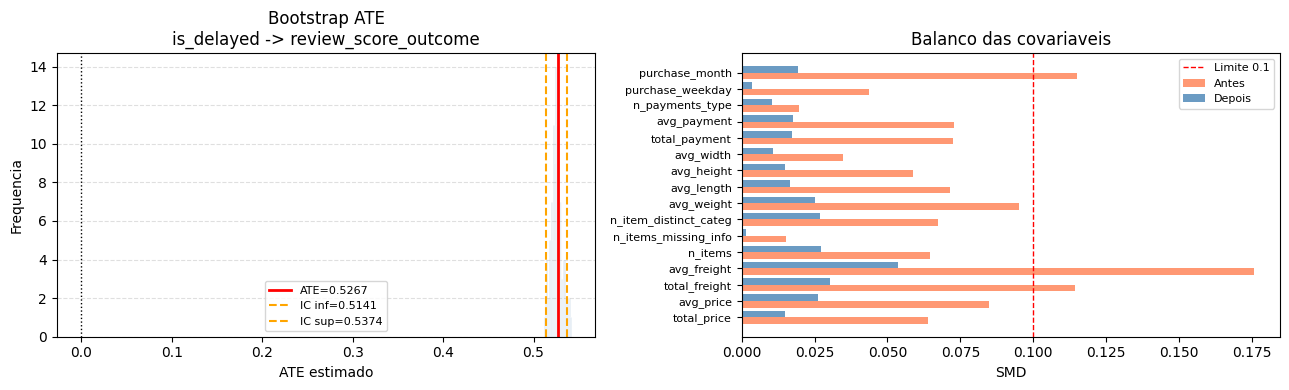

In [8]:
run = run_iptw_analysis(
    df[confounders + [treatment, outcome]], 
    confounders = confounders,
    treatment = treatment, 
    outcome = outcome,
    assoc_bruta = 0.532,
    n_bootstrap = 200
)